<a href="https://colab.research.google.com/github/Gabriela-Sol/VpC2---Deteccion-de-humo-y-fuego/blob/main/notebooks/01_exploracion_dfire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# ============================================================
# Setup general del entorno
# ============================================================

from pathlib import Path
import os
import sys
import random
import yaml
import shutil

SEED = 42
random.seed(SEED)

IN_COLAB = "google.colab" in sys.modules

print("Ejecutando en Google Colab:", IN_COLAB)
print("Directorio actual:", Path.cwd())

Ejecutando en Google Colab: True
Directorio actual: /content/VpC2---Deteccion-de-humo-y-fuego


In [20]:
# ============================================================
# Instalación de dependencias
# ============================================================

REPO_URL = "https://github.com/Gabriela-Sol/VpC2---Deteccion-de-humo-y-fuego"
REPO_NAME = "VpC2---Deteccion-de-humo-y-fuego"

if IN_COLAB:
    !pip install -q -r https://raw.githubusercontent.com/Gabriela-Sol/VpC2---Deteccion-de-humo-y-fuego/main/requirements.txt

print("Dependencias instaladas.")

Dependencias instaladas.


In [21]:
# ============================================================
# Imports del análisis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

from collections import Counter
from matplotlib.patches import Rectangle

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Imports cargados correctamente.")

Imports cargados correctamente.


In [22]:
# ============================================================
# Clonado o actualización del repositorio
# ============================================================

PROJECT_DIR = Path("/content") / REPO_NAME

if IN_COLAB:
    if PROJECT_DIR.exists():
        print("El repositorio ya existe. Actualizando...")
        %cd {PROJECT_DIR}
        !git pull
    else:
        print("Clonando repositorio...")
        %cd /content
        !git clone {REPO_URL}.git
        %cd {PROJECT_DIR}
else:
    PROJECT_DIR = Path.cwd()

print("PROJECT_DIR:", PROJECT_DIR)
print("Contenido del proyecto:")
print(os.listdir(PROJECT_DIR))

El repositorio ya existe. Actualizando...
/content/VpC2---Deteccion-de-humo-y-fuego
Already up to date.
PROJECT_DIR: /content/VpC2---Deteccion-de-humo-y-fuego
Contenido del proyecto:
['02_entrenamiento_YOLO.ipynb', 'demo', 'requirements.txt', 'configs', '.git', '.gitignore', 'data', 'README.md', 'src', 'reports', 'notebooks']


In [23]:
# ============================================================
# Descarga o localización del dataset
# ============================================================

import kagglehub

DATASET_ID = "sayedgamal99/smoke-fire-detection-yolo"

dataset_path = Path(kagglehub.dataset_download(DATASET_ID))

print("Dataset descargado/localizado en:")
print(dataset_path)

print("\nContenido principal:")
for item in dataset_path.iterdir():
    print("-", item.name)

Using Colab cache for faster access to the 'smoke-fire-detection-yolo' dataset.
Dataset descargado/localizado en:
/kaggle/input/smoke-fire-detection-yolo

Contenido principal:
- data.yaml
- data


In [24]:
# ============================================================
# Definición simple de la carpeta de datos
# ============================================================

def is_valid_yolo_dir(path: Path) -> bool:
    """
    Verifica si una carpeta tiene estructura YOLO esperada.
    """
    required_dirs = [
        path / "train" / "images",
        path / "train" / "labels",
        path / "val" / "images",
        path / "val" / "labels",
    ]

    return all(directory.exists() for directory in required_dirs)


possible_data_dirs = [
    dataset_path,
    dataset_path / "data",
]

DATA_DIR = None

for candidate in possible_data_dirs:
    if is_valid_yolo_dir(candidate):
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    print("No se encontró la estructura esperada en las rutas probadas:")
    for candidate in possible_data_dirs:
        print("-", candidate)

    raise FileNotFoundError(
        "No se encontró una estructura YOLO válida. Revisar manualmente el dataset."
    )

print("Carpeta de datos YOLO detectada:")
print(DATA_DIR)

for split in ["train", "val", "test"]:
    split_dir = DATA_DIR / split
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"

    print(f"\nSplit: {split}")
    print("  images existe:", images_dir.exists(), "->", images_dir)
    print("  labels existe:", labels_dir.exists(), "->", labels_dir)

Carpeta de datos YOLO detectada:
/kaggle/input/smoke-fire-detection-yolo/data

Split: train
  images existe: True -> /kaggle/input/smoke-fire-detection-yolo/data/train/images
  labels existe: True -> /kaggle/input/smoke-fire-detection-yolo/data/train/labels

Split: val
  images existe: True -> /kaggle/input/smoke-fire-detection-yolo/data/val/images
  labels existe: True -> /kaggle/input/smoke-fire-detection-yolo/data/val/labels

Split: test
  images existe: True -> /kaggle/input/smoke-fire-detection-yolo/data/test/images
  labels existe: True -> /kaggle/input/smoke-fire-detection-yolo/data/test/labels


In [25]:
# ============================================================
# Conteo general de imágenes y etiquetas
# ============================================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_paths = [
    path
    for split in ["train", "val", "test"]
    for path in (DATA_DIR / split / "images").iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

label_paths = [
    path
    for split in ["train", "val", "test"]
    for path in (DATA_DIR / split / "labels").iterdir()
    if path.suffix.lower() == ".txt"
]

print(f"Cantidad total de imágenes: {len(image_paths)}")
print(f"Cantidad total de etiquetas: {len(label_paths)}")

Cantidad total de imágenes: 21527
Cantidad total de etiquetas: 21527


In [26]:
# ============================================================
# Conteo de imágenes y etiquetas por split
# ============================================================

split_summary = []

for split in ["train", "val", "test"]:
    images_dir = DATA_DIR / split / "images"
    labels_dir = DATA_DIR / split / "labels"

    images = [
        path
        for path in images_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    labels = [
        path
        for path in labels_dir.iterdir()
        if path.suffix.lower() == ".txt"
    ]

    image_stems = {path.stem for path in images}
    label_stems = {path.stem for path in labels}

    empty_labels = sum(
        not path.read_text(encoding="utf-8").strip()
        for path in labels
    )

    split_summary.append({
        "split": split,
        "imagenes": len(images),
        "etiquetas": len(labels),
        "imagenes_sin_etiqueta": len(image_stems - label_stems),
        "etiquetas_sin_imagen": len(label_stems - image_stems),
        "etiquetas_vacias": empty_labels,
    })

df_split_summary = pd.DataFrame(split_summary)
df_split_summary

,split,imagenes,etiquetas,imagenes_sin_etiqueta,etiquetas_sin_imagen,etiquetas_vacias
0,train,14122,14122,0,0,6458
1,val,3099,3099,0,0,1375
2,test,4306,4306,0,0,2005


In [27]:
# ============================================================
# Funciones para lectura de etiquetas YOLO
# ============================================================

CLASS_NAMES = {
    0: "smoke",
    1: "fire",
}

def read_yolo_label(label_path: Path) -> list:
    """
    Lee un archivo de etiquetas YOLO.

    Returns
    -------
    list of dict
        Cada elemento representa una bounding box.
    """
    content = label_path.read_text(encoding="utf-8").strip()

    if content == "":
        return []

    boxes = []

    for line in content.splitlines():
        parts = line.split()

        if len(parts) != 5:
            continue

        class_id = int(float(parts[0]))
        x_center, y_center, width, height = map(float, parts[1:])

        boxes.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES.get(class_id, f"class_{class_id}"),
            "x_center": x_center,
            "y_center": y_center,
            "width": width,
            "height": height,
        })

    return boxes


def get_label_path_from_image(image_path: Path) -> Path:
    """
    Obtiene el path de la etiqueta asociada a una imagen.
    """
    return Path(
        str(image_path)
        .replace("/images/", "/labels/")
    ).with_suffix(".txt")

In [28]:
# ============================================================
# Clasificación de imágenes por tipo de contenido
# ============================================================

image_records = []

for image_path in image_paths:
    split = image_path.parts[image_path.parts.index(DATA_DIR.name) + 1] if DATA_DIR.name in image_path.parts else None

    # Forma más robusta para determinar split
    for possible_split in ["train", "val", "test"]:
        if f"/{possible_split}/images/" in str(image_path):
            split = possible_split
            break

    label_path = get_label_path_from_image(image_path)
    boxes = read_yolo_label(label_path) if label_path.exists() else []

    class_ids = {box["class_id"] for box in boxes}

    if len(class_ids) == 0:
        image_type = "negative"
    elif class_ids == {0}:
        image_type = "smoke"
    elif class_ids == {1}:
        image_type = "fire"
    elif class_ids == {0, 1}:
        image_type = "smoke_and_fire"
    else:
        image_type = "other"

    image_records.append({
        "split": split,
        "image_path": str(image_path),
        "label_path": str(label_path),
        "image_type": image_type,
        "n_boxes": len(boxes),
        "has_smoke": 0 in class_ids,
        "has_fire": 1 in class_ids,
    })

df_images = pd.DataFrame(image_records)

df_images.head()

,split,image_path,label_path,image_type,n_boxes,has_smoke,has_fire
0,train,/kaggle/input/smoke-fire-detection-yolo/data/t...,/kaggle/input/smoke-fire-detection-yolo/data/t...,smoke,1,True,False
1,train,/kaggle/input/smoke-fire-detection-yolo/data/t...,/kaggle/input/smoke-fire-detection-yolo/data/t...,negative,0,False,False
2,train,/kaggle/input/smoke-fire-detection-yolo/data/t...,/kaggle/input/smoke-fire-detection-yolo/data/t...,negative,0,False,False
3,train,/kaggle/input/smoke-fire-detection-yolo/data/t...,/kaggle/input/smoke-fire-detection-yolo/data/t...,negative,0,False,False
4,train,/kaggle/input/smoke-fire-detection-yolo/data/t...,/kaggle/input/smoke-fire-detection-yolo/data/t...,negative,0,False,False


In [29]:
# ============================================================
# Distribución de tipos de imagen por split
# ============================================================

df_image_types = (
    df_images
    .groupby(["split", "image_type"])
    .size()
    .reset_index(name="cantidad")
    .sort_values(["split", "image_type"])
)

df_image_types

,split,image_type,cantidad
0,test,fire,220
1,test,negative,2005
2,test,smoke,1186
3,test,smoke_and_fire,895
4,train,fire,770
5,train,negative,6458
6,train,smoke,3836
7,train,smoke_and_fire,3058
8,val,fire,174
9,val,negative,1375


In [38]:
# ============================================================
# Tabla resumen por split y tipo de imagen
# ============================================================

df_image_types_pivot = (
    df_image_types
    .pivot(index="split", columns="image_type", values="cantidad")
    .fillna(0)
    .astype(int)
)

df_image_types_pivot

image_type,fire,negative,smoke,smoke_and_fire
split,,,,
test,220,2005,1186,895
train,770,6458,3836,3058
val,174,1375,845,705


In [64]:
# ============================================================
# Directorio para guardar figuras del EDA
# ============================================================

EDA_FIGURES_DIR = PROJECT_DIR / "reports" / "figures" / "eda"
EDA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Las figuras del EDA se guardarán en:")
print(EDA_FIGURES_DIR)

Las figuras del EDA se guardarán en:
/content/VpC2---Deteccion-de-humo-y-fuego/reports/figures/eda


Figura guardada en: /content/VpC2---Deteccion-de-humo-y-fuego/reports/figures/eda/image_type_distribution.png


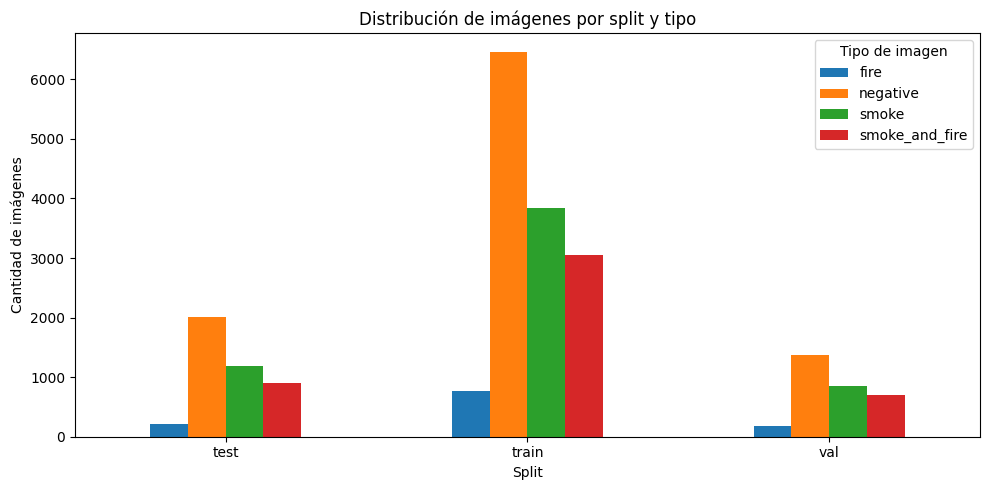

In [65]:
# ============================================================
# Visualización de distribución de imágenes
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

df_image_types_pivot.plot(
    kind="bar",
    ax=ax,
    rot=0,
)

ax.set_title("Distribución de imágenes por split y tipo")
ax.set_xlabel("Split")
ax.set_ylabel("Cantidad de imágenes")
ax.legend(title="Tipo de imagen")

plt.tight_layout()

output_path = EDA_FIGURES_DIR / "image_type_distribution.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

print("Figura guardada en:", output_path)

plt.show()

In [40]:
# ============================================================
# Conteo de bounding boxes por clase
# ============================================================

box_records = []

for _, row in df_images.iterrows():
    label_path = Path(row["label_path"])

    if not label_path.exists():
        continue

    boxes = read_yolo_label(label_path)

    for box in boxes:
        box_records.append({
            "split": row["split"],
            "image_path": row["image_path"],
            "label_path": row["label_path"],
            "class_id": box["class_id"],
            "class_name": box["class_name"],
            "x_center": box["x_center"],
            "y_center": box["y_center"],
            "width": box["width"],
            "height": box["height"],
            "area": box["width"] * box["height"],
        })

df_boxes = pd.DataFrame(box_records)

print("Cantidad total de bounding boxes:", len(df_boxes))
df_boxes.head()

Cantidad total de bounding boxes: 26557


,split,image_path,label_path,class_id,class_name,x_center,y_center,width,height,area
0,train,/kaggle/input/smoke-fire-detection-yolo/data/t...,/kaggle/input/smoke-fire-detection-yolo/data/t...,0,smoke,0.331481,0.361111,0.574074,0.566667,0.325309
1,train,/kaggle/input/smoke-fire-detection-yolo/data/t...,/kaggle/input/smoke-fire-detection-yolo/data/t...,0,smoke,0.422500,0.413677,0.315000,0.500000,0.157500
2,train,/kaggle/input/smoke-fire-detection-yolo/data/t...,/kaggle/input/smoke-fire-detection-yolo/data/t...,1,fire,0.461328,0.170833,0.107031,0.272222,0.029136
3,train,/kaggle/input/smoke-fire-detection-yolo/data/t...,/kaggle/input/smoke-fire-detection-yolo/data/t...,1,fire,0.510938,0.400000,0.178125,0.300000,0.053437
4,train,/kaggle/input/smoke-fire-detection-yolo/data/t...,/kaggle/input/smoke-fire-detection-yolo/data/t...,1,fire,0.650000,0.561111,0.090625,0.138889,0.012587


In [41]:
# ============================================================
# Distribución de bounding boxes por clase y split
# ============================================================

df_boxes_summary = (
    df_boxes
    .groupby(["split", "class_name"])
    .size()
    .reset_index(name="cantidad_boxes")
    .sort_values(["split", "class_name"])
)

df_boxes_summary

,split,class_name,cantidad_boxes
0,test,fire,2878
1,test,smoke,2315
2,train,fire,9638
3,train,smoke,7794
4,val,fire,2176
5,val,smoke,1756


Figura guardada en: /content/VpC2---Deteccion-de-humo-y-fuego/reports/figures/eda/boxes_by_class_and_split.png


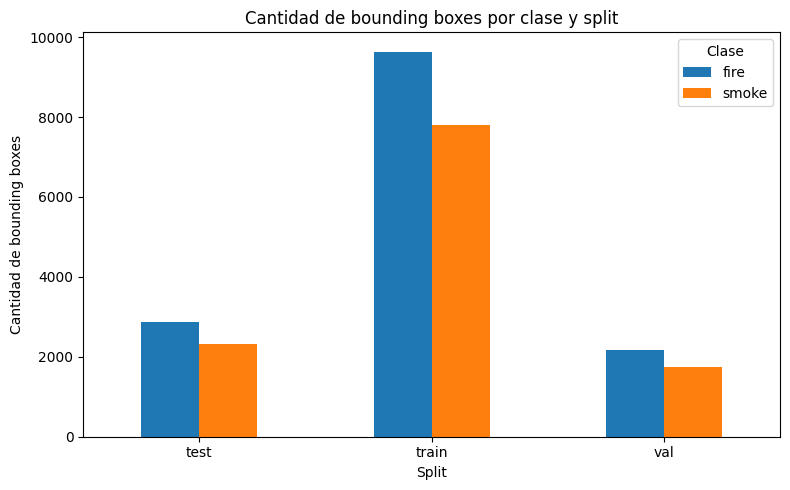

In [66]:
# ============================================================
# Visualización de bounding boxes por clase
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

df_boxes_pivot.plot(
    kind="bar",
    ax=ax,
    rot=0,
)

ax.set_title("Cantidad de bounding boxes por clase y split")
ax.set_xlabel("Split")
ax.set_ylabel("Cantidad de bounding boxes")
ax.legend(title="Clase")

plt.tight_layout()

output_path = EDA_FIGURES_DIR / "boxes_by_class_and_split.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

print("Figura guardada en:", output_path)

plt.show()

In [31]:
# ============================================================
# Validación de anotaciones YOLO
# ============================================================

def validate_yolo_labels(labels_dir: Path) -> dict:
    """
    Valida archivos de etiquetas YOLO.

    Revisa:
    - cantidad de campos;
    - tipo de dato;
    - clases permitidas;
    - coordenadas normalizadas entre 0 y 1.
    """
    invalid_entries = []
    empty_files = 0
    total_boxes = 0

    for label_path in labels_dir.glob("*.txt"):
        content = label_path.read_text(encoding="utf-8").strip()

        if content == "":
            empty_files += 1
            continue

        for line_number, line in enumerate(content.splitlines(), start=1):
            parts = line.split()

            if len(parts) != 5:
                invalid_entries.append({
                    "file": str(label_path),
                    "line_number": line_number,
                    "error": "Cantidad de campos distinta de 5",
                    "line": line,
                })
                continue

            try:
                class_id = int(float(parts[0]))
                coords = list(map(float, parts[1:]))
            except ValueError:
                invalid_entries.append({
                    "file": str(label_path),
                    "line_number": line_number,
                    "error": "Valores no numéricos",
                    "line": line,
                })
                continue

            if class_id not in CLASS_NAMES:
                invalid_entries.append({
                    "file": str(label_path),
                    "line_number": line_number,
                    "error": "Clase fuera de rango",
                    "line": line,
                })
                continue

            if not all(0 <= value <= 1 for value in coords):
                invalid_entries.append({
                    "file": str(label_path),
                    "line_number": line_number,
                    "error": "Coordenadas fuera de [0, 1]",
                    "line": line,
                })
                continue

            total_boxes += 1

    return {
        "empty_files": empty_files,
        "total_boxes": total_boxes,
        "invalid_entries": invalid_entries,
    }


validation_results = []

for split in ["train", "val", "test"]:
    labels_dir = DATA_DIR / split / "labels"
    validation = validate_yolo_labels(labels_dir)

    validation_results.append({
        "split": split,
        "labels_vacios": validation["empty_files"],
        "boxes_validos": validation["total_boxes"],
        "entradas_problematicas": len(validation["invalid_entries"]),
    })

    print(f"\nSplit: {split}")
    print("Labels vacíos:", validation["empty_files"])
    print("Bounding boxes válidos:", validation["total_boxes"])
    print("Entradas problemáticas:", len(validation["invalid_entries"]))

    if validation["invalid_entries"][:5]:
        print("Primeras entradas problemáticas:")
        for entry in validation["invalid_entries"][:5]:
            print(entry)

df_validation = pd.DataFrame(validation_results)
df_validation


Split: train
Labels vacíos: 6458
Bounding boxes válidos: 17432
Entradas problemáticas: 0

Split: val
Labels vacíos: 1375
Bounding boxes válidos: 3932
Entradas problemáticas: 0

Split: test
Labels vacíos: 2005
Bounding boxes válidos: 5185
Entradas problemáticas: 8
Primeras entradas problemáticas:
{'file': '/kaggle/input/smoke-fire-detection-yolo/data/test/labels/WEB11606.txt', 'line_number': 1, 'error': 'Coordenadas fuera de [0, 1]', 'line': '0 0.2578125 0.4986111111111111 0.50625 1.0027777777777778'}
{'file': '/kaggle/input/smoke-fire-detection-yolo/data/test/labels/WEB11600.txt', 'line_number': 1, 'error': 'Coordenadas fuera de [0, 1]', 'line': '0 0.496875 0.4222222222222222 1.0562500000000001 0.8388888888888889'}
{'file': '/kaggle/input/smoke-fire-detection-yolo/data/test/labels/WEB11090.txt', 'line_number': 1, 'error': 'Coordenadas fuera de [0, 1]', 'line': '0 0.5437500000000001 0.5013888888888889 0.5375 1.0027777777777778'}
{'file': '/kaggle/input/smoke-fire-detection-yolo/data/te

,split,labels_vacios,boxes_validos,entradas_problematicas
0,train,6458,17432,0
1,val,1375,3932,0
2,test,2005,5185,8


In [43]:
# ============================================================
# Consolidación de anotaciones problemáticas
# ============================================================

invalid_entries_all = []

for split in ["train", "val", "test"]:
    labels_dir = DATA_DIR / split / "labels"
    validation = validate_yolo_labels(labels_dir)

    for entry in validation["invalid_entries"]:
        entry["split"] = split
        invalid_entries_all.append(entry)

df_invalid_entries = pd.DataFrame(invalid_entries_all)

print("Cantidad total de entradas problemáticas:", len(df_invalid_entries))

if not df_invalid_entries.empty:
    display(df_invalid_entries.head(20))
else:
    print("No se encontraron entradas problemáticas.")

Cantidad total de entradas problemáticas: 8


,file,line_number,error,line,split
0,/kaggle/input/smoke-fire-detection-yolo/data/t...,1,"Coordenadas fuera de [0, 1]",0 0.2578125 0.4986111111111111 0.50625 1.00277...,test
1,/kaggle/input/smoke-fire-detection-yolo/data/t...,1,"Coordenadas fuera de [0, 1]",0 0.496875 0.4222222222222222 1.05625000000000...,test
2,/kaggle/input/smoke-fire-detection-yolo/data/t...,1,"Coordenadas fuera de [0, 1]",0 0.5437500000000001 0.5013888888888889 0.5375...,test
3,/kaggle/input/smoke-fire-detection-yolo/data/t...,3,"Coordenadas fuera de [0, 1]",0 0.49843750000000003 0.3388888888888889 1.009...,test
4,/kaggle/input/smoke-fire-detection-yolo/data/t...,2,"Coordenadas fuera de [0, 1]",0 0.50546875 0.3625 1.0296875 0.7083333333333334,test
5,/kaggle/input/smoke-fire-detection-yolo/data/t...,3,"Coordenadas fuera de [0, 1]",0 0.496875 0.27083333333333337 1.015625 0.5750...,test
6,/kaggle/input/smoke-fire-detection-yolo/data/t...,2,"Coordenadas fuera de [0, 1]",0 0.50703125 0.3625 1.0078125 0.7138888888888889,test
7,/kaggle/input/smoke-fire-detection-yolo/data/t...,1,"Coordenadas fuera de [0, 1]",0 0.49921875000000004 0.4013888888888889 1.035...,test


In [68]:
# ============================================================
# Funciones de visualización de anotaciones
# ============================================================

def draw_yolo_boxes(image_path: Path, label_path: Path, class_names: dict) -> np.ndarray:
    """
    Dibuja bounding boxes YOLO sobre una imagen.
    """
    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]

    boxes = read_yolo_label(label_path) if label_path.exists() else []

    for box in boxes:
        class_id = box["class_id"]
        class_name = class_names.get(class_id, str(class_id))

        x_center = box["x_center"] * width
        y_center = box["y_center"] * height
        box_width = box["width"] * width
        box_height = box["height"] * height

        x1 = int(x_center - box_width / 2)
        y1 = int(y_center - box_height / 2)
        x2 = int(x_center + box_width / 2)
        y2 = int(y_center + box_height / 2)

        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(
            image,
            class_name,
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2,
            cv2.LINE_AA,
        )

    return image


def show_samples_by_type(
    df: pd.DataFrame,
    image_type: str,
    n: int = 4,
    save_dir: Path | None = None,
) -> None:
    """
    Muestra y opcionalmente guarda ejemplos de un tipo de imagen:
    negative, smoke, fire o smoke_and_fire.
    """
    subset = df[df["image_type"] == image_type]

    if subset.empty:
        print(f"No hay ejemplos para image_type={image_type}")
        return

    samples = subset.sample(
        n=min(n, len(subset)),
        random_state=SEED
    )

    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))

    if len(samples) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, samples.iterrows()):
        image_path = Path(row["image_path"])
        label_path = Path(row["label_path"])

        image = draw_yolo_boxes(image_path, label_path, CLASS_NAMES)

        ax.imshow(image)
        ax.set_title(f"{row['split']} | {row['image_type']}")
        ax.axis("off")

    plt.tight_layout()

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        output_path = save_dir / f"samples_{image_type}.png"
        fig.savefig(output_path, dpi=150, bbox_inches="tight")
        print("Figura guardada en:", output_path)

    plt.show()

Figura guardada en: /content/VpC2---Deteccion-de-humo-y-fuego/reports/figures/eda/bbox_area_distribution.png


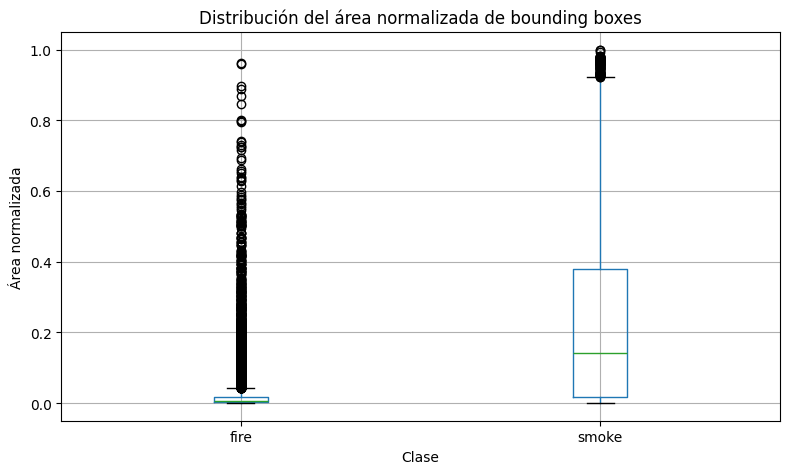

In [67]:
# ============================================================
# Distribución de áreas de bounding boxes
# ============================================================

if not df_boxes.empty:
    fig, ax = plt.subplots(figsize=(8, 5))

    df_boxes.boxplot(
        column="area",
        by="class_name",
        ax=ax,
    )

    ax.set_title("Distribución del área normalizada de bounding boxes")
    ax.set_xlabel("Clase")
    ax.set_ylabel("Área normalizada")

    plt.suptitle("")
    plt.tight_layout()

    output_path = EDA_FIGURES_DIR / "bbox_area_distribution.png"
    fig.savefig(output_path, dpi=150, bbox_inches="tight")

    print("Figura guardada en:", output_path)

    plt.show()
else:
    print("No hay bounding boxes para graficar.")

Figura guardada en: /content/VpC2---Deteccion-de-humo-y-fuego/reports/figures/eda/samples_negative.png


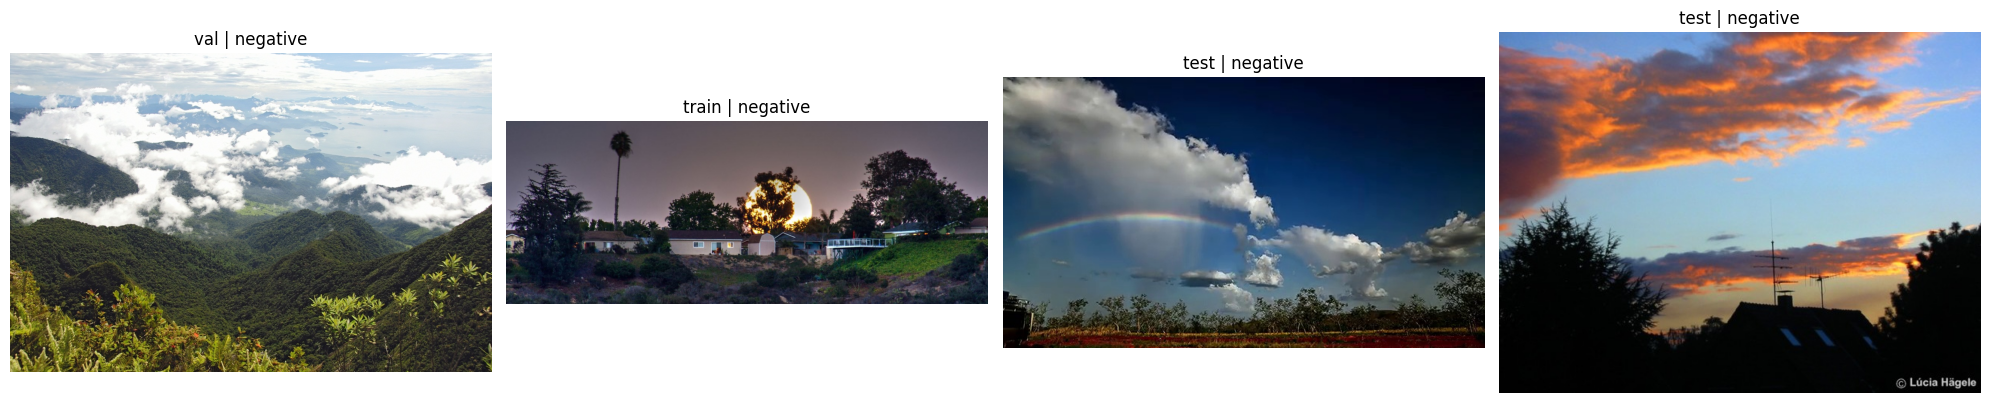

In [70]:
# ============================================================
# Ejemplos negativos
# ============================================================

show_samples_by_type(
    df_images,
    image_type="negative",
    n=4,
    save_dir=EDA_FIGURES_DIR,
)

Figura guardada en: /content/VpC2---Deteccion-de-humo-y-fuego/reports/figures/eda/samples_smoke.png


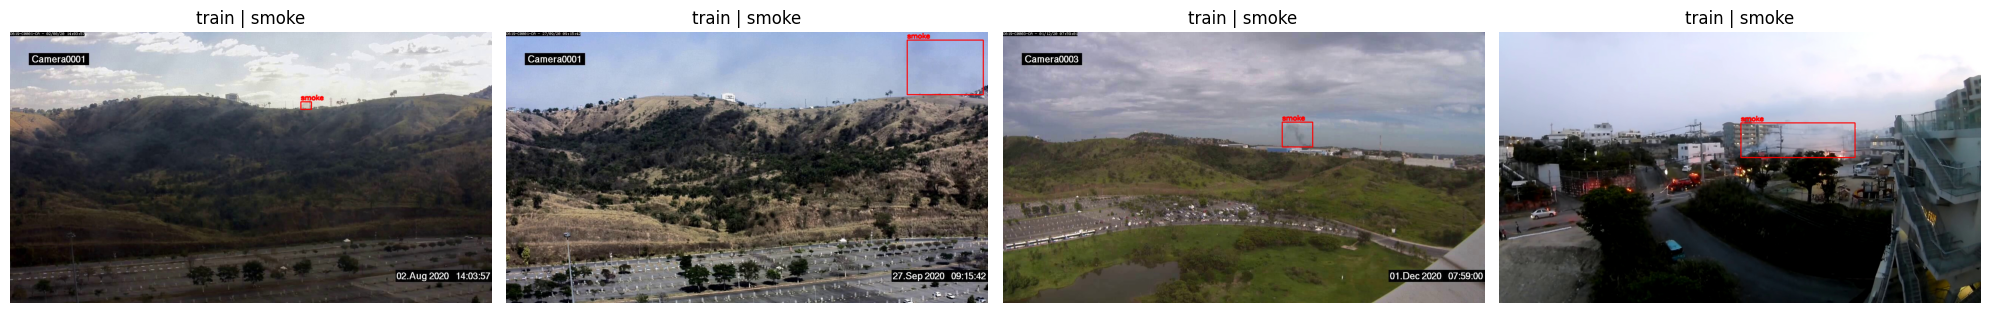

In [71]:
# ============================================================
# Ejemplos con humo
# ============================================================

show_samples_by_type(
    df_images,
    image_type="smoke",
    n=4,
    save_dir=EDA_FIGURES_DIR,
)

Figura guardada en: /content/VpC2---Deteccion-de-humo-y-fuego/reports/figures/eda/samples_fire.png


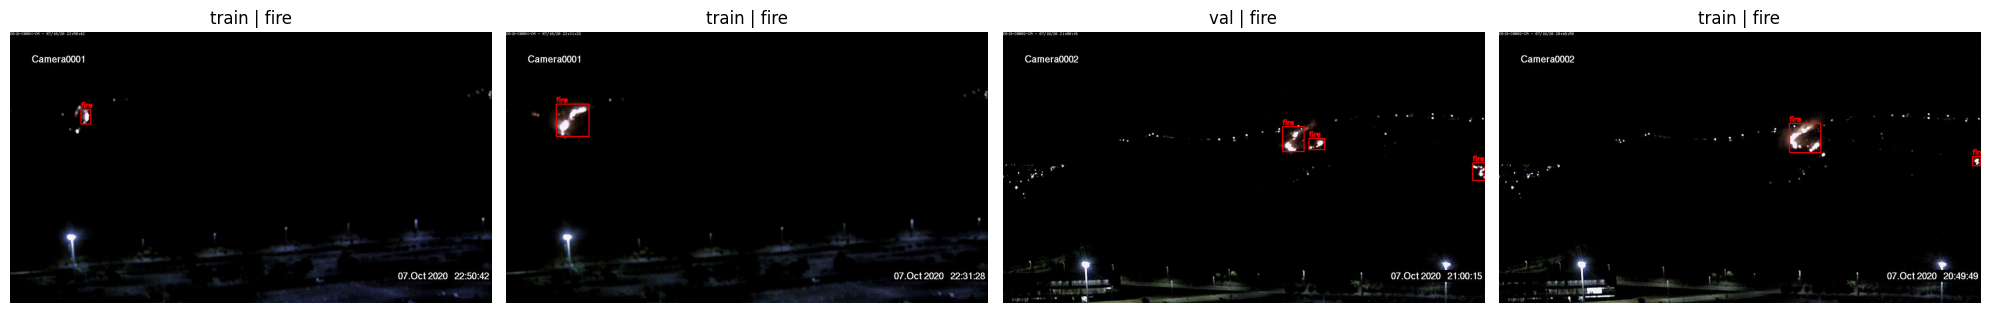

In [72]:
# ============================================================
# Ejemplos con fuego
# ============================================================

show_samples_by_type(
    df_images,
    image_type="fire",
    n=4,
    save_dir=EDA_FIGURES_DIR,
)

Figura guardada en: /content/VpC2---Deteccion-de-humo-y-fuego/reports/figures/eda/samples_smoke_and_fire.png


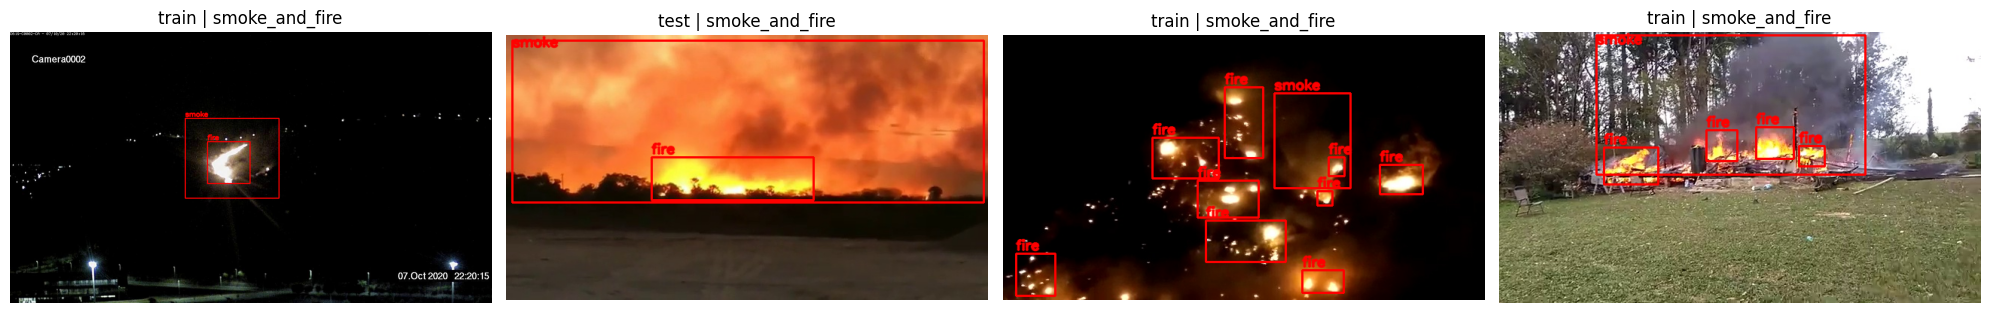

In [73]:
# ============================================================
# Ejemplos con humo y fuego
# ============================================================

show_samples_by_type(
    df_images,
    image_type="smoke_and_fire",
    n=4,
    save_dir=EDA_FIGURES_DIR,
)

In [74]:
# ============================================================
# Verificación de figuras generadas
# ============================================================

print("Figuras guardadas en:")
print(EDA_FIGURES_DIR)

for item in sorted(EDA_FIGURES_DIR.iterdir()):
    print("-", item.name)

Figuras guardadas en:
/content/VpC2---Deteccion-de-humo-y-fuego/reports/figures/eda
- bbox_area_distribution.png
- boxes_by_class_and_split.png
- image_type_distribution.png
- samples_fire.png
- samples_negative.png
- samples_smoke.png
- samples_smoke_and_fire.png


In [75]:
# ============================================================
# Creación del archivo YAML dinámico para YOLO
# ============================================================

from pathlib import Path
import yaml

# Validación mínima de estructura esperada
required_dirs = [
    DATA_DIR / "train" / "images",
    DATA_DIR / "train" / "labels",
    DATA_DIR / "val" / "images",
    DATA_DIR / "val" / "labels",
    DATA_DIR / "test" / "images",
    DATA_DIR / "test" / "labels",
]

missing_dirs = [path for path in required_dirs if not path.exists()]

if missing_dirs:
    print("Faltan las siguientes carpetas:")
    for path in missing_dirs:
        print("-", path)
    raise FileNotFoundError("La estructura del dataset no es válida para YOLO.")

# Archivo YAML dinámico para usar en esta sesión de Colab
DFIRE_YAML = Path("/content/dfire_colab.yaml")

dfire_config = {
    "path": str(DATA_DIR),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 2,
    "names": {
        0: "smoke",
        1: "fire",
    },
}

with open(DFIRE_YAML, "w", encoding="utf-8") as file:
    yaml.safe_dump(
        dfire_config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print("Archivo YAML creado correctamente en:")
print(DFIRE_YAML)

print("\nContenido del YAML:")
with open(DFIRE_YAML, "r", encoding="utf-8") as file:
    print(file.read())

Archivo YAML creado correctamente en:
/content/dfire_colab.yaml

Contenido del YAML:
path: /kaggle/input/smoke-fire-detection-yolo/data
train: train/images
val: val/images
test: test/images
nc: 2
names:
  0: smoke
  1: fire



In [76]:
# ============================================================
# Guardar copia del YAML usado dentro del repositorio local
# ============================================================

EDA_RESULTS_DIR = PROJECT_DIR / "reports" / "results" / "eda"
EDA_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DFIRE_YAML_USED = EDA_RESULTS_DIR / "dfire_colab_used.yaml"

with open(DFIRE_YAML_USED, "w", encoding="utf-8") as file:
    yaml.safe_dump(
        dfire_config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print("Copia del YAML guardada en:")
print(DFIRE_YAML_USED)

print("\nArchivos actuales en reports/results/eda:")
for item in sorted(EDA_RESULTS_DIR.iterdir()):
    print("-", item.name)

Copia del YAML guardada en:
/content/VpC2---Deteccion-de-humo-y-fuego/reports/results/eda/dfire_colab_used.yaml

Archivos actuales en reports/results/eda:
- boxes_summary.csv
- dfire_colab_used.yaml
- image_types_summary.csv
- invalid_entries.csv
- label_validation_summary.csv
- split_summary.csv


In [77]:
# ============================================================
# Exportar resultados tabulares del EDA al repositorio local
# ============================================================

EDA_RESULTS_DIR = PROJECT_DIR / "reports" / "results" / "eda"
EDA_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

outputs_to_save = {
    "split_summary.csv": df_split_summary,
    "image_types_summary.csv": df_image_types,
    "boxes_summary.csv": df_boxes_summary,
    "label_validation_summary.csv": df_validation,
}

for filename, dataframe in outputs_to_save.items():
    output_path = EDA_RESULTS_DIR / filename
    dataframe.to_csv(output_path, index=False)
    print("Guardado:", output_path)

if "df_invalid_entries" in globals() and not df_invalid_entries.empty:
    invalid_entries_path = EDA_RESULTS_DIR / "invalid_entries.csv"
    df_invalid_entries.to_csv(invalid_entries_path, index=False)
    print("Guardado:", invalid_entries_path)
else:
    print("No se encontraron anotaciones problemáticas para exportar.")

print("\nResultados tabulares del EDA exportados en:")
print(EDA_RESULTS_DIR)

print("\nArchivos generados:")
for item in sorted(EDA_RESULTS_DIR.iterdir()):
    print("-", item.name)

Guardado: /content/VpC2---Deteccion-de-humo-y-fuego/reports/results/eda/split_summary.csv
Guardado: /content/VpC2---Deteccion-de-humo-y-fuego/reports/results/eda/image_types_summary.csv
Guardado: /content/VpC2---Deteccion-de-humo-y-fuego/reports/results/eda/boxes_summary.csv
Guardado: /content/VpC2---Deteccion-de-humo-y-fuego/reports/results/eda/label_validation_summary.csv
Guardado: /content/VpC2---Deteccion-de-humo-y-fuego/reports/results/eda/invalid_entries.csv

Resultados tabulares del EDA exportados en:
/content/VpC2---Deteccion-de-humo-y-fuego/reports/results/eda

Archivos generados:
- boxes_summary.csv
- dfire_colab_used.yaml
- image_types_summary.csv
- invalid_entries.csv
- label_validation_summary.csv
- split_summary.csv


In [78]:
# ============================================================
# Commit y push seguro al repositorio real de GitHub
# ============================================================

from getpass import getpass
import subprocess
from pathlib import Path

%cd {PROJECT_DIR}

# ------------------------------------------------------------
# Configuración de usuario para el commit
# ------------------------------------------------------------

!git config user.name "Gabriela-Sol"
!git config user.email "solgab.salazar@gmail.com"

print("Estado inicial:")
!git status -sb

# ------------------------------------------------------------
# Traer cambios remotos antes de pushear
# ------------------------------------------------------------

print("\nActualizando rama local con cambios remotos...")
pull_result = subprocess.run(
    ["git", "pull", "--rebase", "origin", "main"],
    text=True,
    capture_output=True,
)

print(pull_result.stdout)
print(pull_result.stderr)

if pull_result.returncode != 0:
    print("Hubo un problema durante el pull --rebase.")
    print("Revisar si hay conflictos antes de continuar.")
    raise RuntimeError("No se pudo completar git pull --rebase.")

print("\nEstado después del pull --rebase:")
!git status -sb

# ------------------------------------------------------------
# Agregar archivos del EDA
# ------------------------------------------------------------

paths_to_add = [
    "reports/results/eda/",
    "reports/figures/eda/",
]

print("\nAgregando archivos al commit:")

for path in paths_to_add:
    if Path(path).exists():
        subprocess.run(["git", "add", path], check=True)
        print("Agregado:", path)
    else:
        print("No existe, se omite:", path)

print("\nEstado después de git add:")
status_result = subprocess.run(
    ["git", "status", "--short"],
    text=True,
    capture_output=True,
)

print(status_result.stdout)

# ------------------------------------------------------------
# Commit solo si hay cambios
# ------------------------------------------------------------

if not status_result.stdout.strip():
    print("No hay cambios nuevos para commitear.")
else:
    commit_message = "results: update EDA outputs"

    commit_result = subprocess.run(
        ["git", "commit", "-m", commit_message],
        text=True,
        capture_output=True,
    )

    print("\nSalida del commit:")
    print(commit_result.stdout)
    print(commit_result.stderr)

    if commit_result.returncode != 0:
        print("No se pudo crear el commit.")
        raise RuntimeError("Error en git commit.")

# ------------------------------------------------------------
# Push seguro con token
# ------------------------------------------------------------

print("\nEstado antes del push:")
!git status -sb

github_token = getpass("Pegá tu GitHub token: ")

repo_url = (
    f"https://x-access-token:{github_token}"
    "@github.com/Gabriela-Sol/VpC2---Deteccion-de-humo-y-fuego.git"
)

push_result = subprocess.run(
    ["git", "push", repo_url, "HEAD:main"],
    text=True,
    capture_output=True,
)

def sanitize(text):
    if github_token:
        return text.replace(github_token, "***TOKEN***")
    return text

print("\nReturn code push:", push_result.returncode)

if push_result.returncode == 0:
    print("Push realizado correctamente.")
else:
    print("Error en el push:")
    print(sanitize(push_result.stdout))
    print(sanitize(push_result.stderr))

github_token = None
repo_url = None

print("\nEstado final:")
!git status -sb

/content/VpC2---Deteccion-de-humo-y-fuego
Estado inicial:
## main...origin/main [ahead 1]
?? reports/figures/
?? reports/results/eda/dfire_colab_used.yaml

Actualizando rama local con cambios remotos...
Already up to date.

From https://github.com/Gabriela-Sol/VpC2---Deteccion-de-humo-y-fuego
 * branch            main       -> FETCH_HEAD
   e5a08d1..770d6cd  main       -> origin/main


Estado después del pull --rebase:
## main...origin/main
?? reports/figures/
?? reports/results/eda/dfire_colab_used.yaml

Agregando archivos al commit:
Agregado: reports/results/eda/
Agregado: reports/figures/eda/

Estado después de git add:
A  reports/figures/eda/bbox_area_distribution.png
A  reports/figures/eda/boxes_by_class_and_split.png
A  reports/figures/eda/image_type_distribution.png
A  reports/figures/eda/samples_fire.png
A  reports/figures/eda/samples_negative.png
A  reports/figures/eda/samples_smoke.png
A  reports/figures/eda/samples_smoke_and_fire.png
A  reports/results/eda/dfire_colab_used.y